In [1]:
#%pip install matplotlib seaborn

In [2]:
# importing libraries
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load dataset
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,NaN,192261.83
1,162597.70,151377.59,443898.53,NaN,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


<Figure size 1000x1000 with 0 Axes>

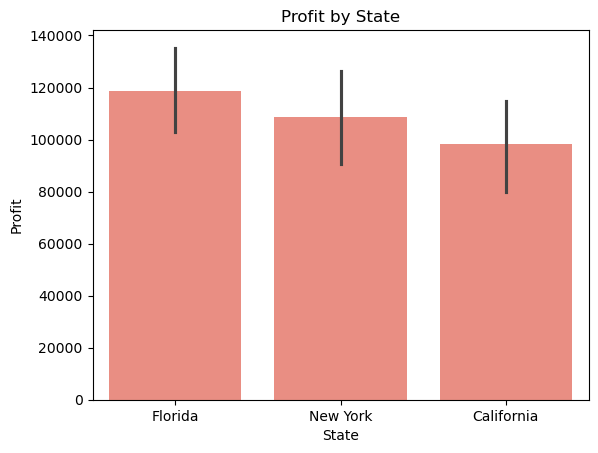

<Figure size 1000x1000 with 0 Axes>

In [3]:
sns.barplot(x='State', y='Profit',data= df,color = "salmon")
plt.title('Profit by State')
plt.figure(figsize=(10,10))

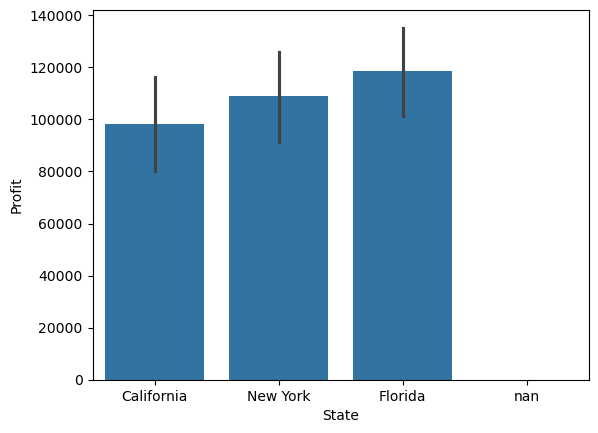

In [4]:
# Sort data using ascending order
sns.barplot(x="State",y="Profit",data=df,
           order=df.sort_values('Profit',ascending=True).State); plt.show()

/var/folders/td/x0tmvm6n1dn552__97jmrspr0000gn/T/ipykernel_90438/3232385461.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["State"] = df["State"].astype(str)      # ensuring state column is treated as categorical


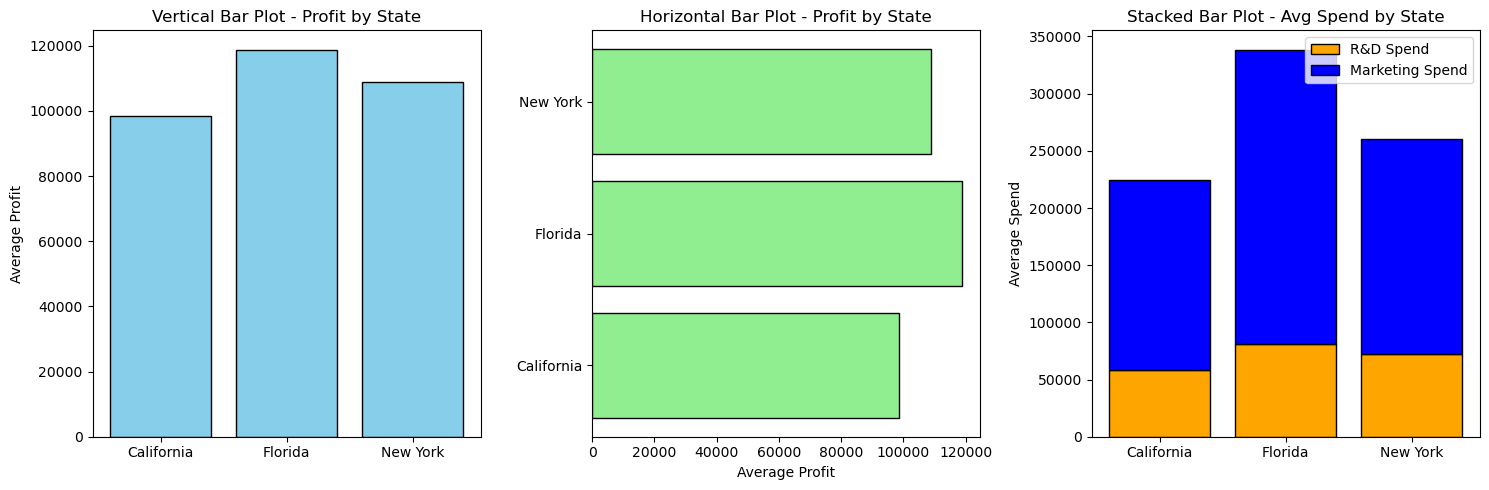

In [5]:
# Drop rows where State is missing
df = df.dropna(subset=["State"])   # Remove rows with missing satet values

# Ensure State is treated as string (important for plotting categories)
df["State"] = df["State"].astype(str)      # ensuring state column is treated as categorical 

# Group data by State
state_profit = df.groupby("State")["Profit"].mean()  # calculate avg profit for each other

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Vertical Bar Plot - Profit by State create 3 side by side plots(1 row , 3 columns) axes array of 3 plot axes[0],[1],[3]
axes[0].bar(state_profit.index, state_profit.values, color="skyblue", edgecolor="black")
axes[0].set_title("Vertical Bar Plot - Profit by State")
axes[0].set_ylabel("Average Profit")

# 2. Horizontal Bar Plot (barh is bar.horizontal)
axes[1].barh(state_profit.index, state_profit.values, color="lightgreen", edgecolor="black")
axes[1].set_title("Horizontal Bar Plot - Profit by State")
axes[1].set_xlabel("Average Profit")

# 3. Stacked Bar Plot - R&D vs Marketing Spend((1st bar-R& D spend),(2nd bar -stacked on top of R&D spend Marketing spend))
rnd_spend = df.groupby("State")["R&D Spend"].mean()
marketing_spend = df.groupby("State")["Marketing Spend"].mean()

axes[2].bar(rnd_spend.index, rnd_spend.values, label="R&D Spend", color="orange", edgecolor="black")
axes[2].bar(marketing_spend.index, marketing_spend.values, bottom=rnd_spend.values,
            label="Marketing Spend", color="blue", edgecolor="black")
axes[2].set_title("Stacked Bar Plot - Avg Spend by State")
axes[2].set_ylabel("Average Spend")
axes[2].legend()

# adjusts spacing to aviod overlap
plt.tight_layout()
plt.show()


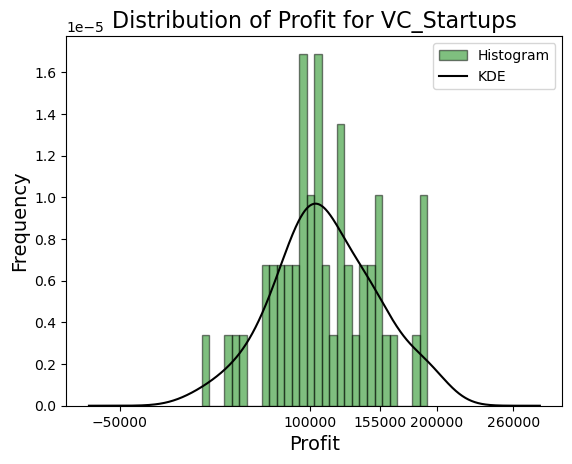

In [6]:
# Loading the Data
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')
profits = df["Profit"]
profits.plot(kind = "hist", bins = 30, color = "green", alpha=0.5, density=True, edgecolor='black' )
profits.plot(kind= "kde",color = "black")

plt.xlabel('Profit', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Profit for VC_Startups', fontsize=16)
plt.xticks([-50000, 100000,155000, 200000, 260000])

# Showing the plot
plt.legend(['Histogram', 'KDE'])
plt.show()

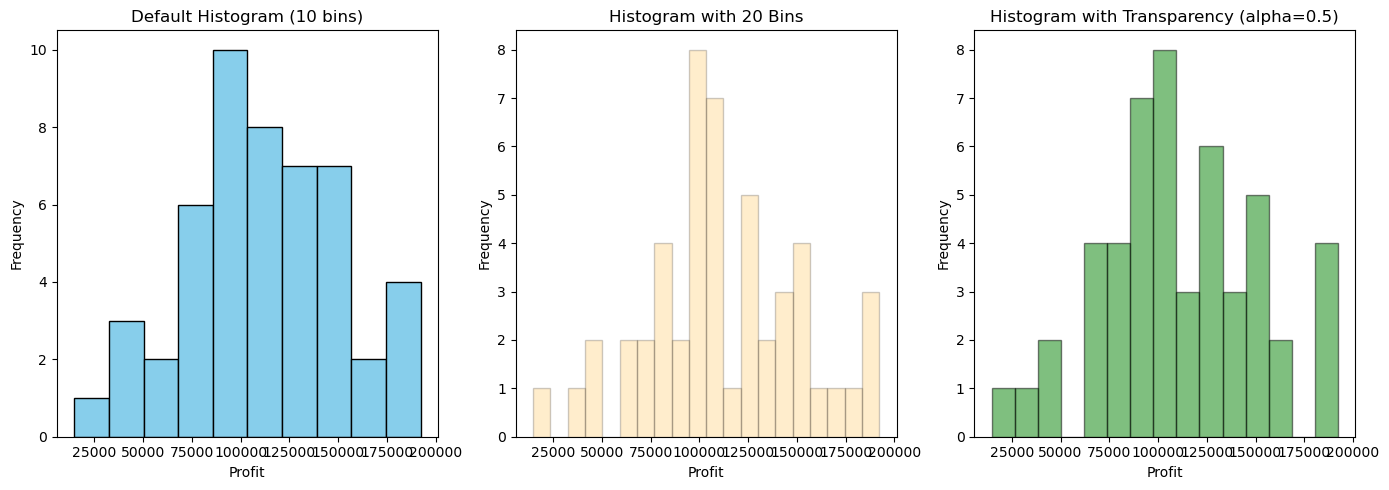

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')

# Drop missing values for Profit column
df = df.dropna(subset=["Profit"])

# Create figur
plt.figure(figsize=(14,5))

# 1. Default Histogram (10 bins)
plt.subplot(1,3,1)
plt.hist(df["Profit"], color="skyblue", alpha=1,edgecolor="black")
plt.title("Default Histogram (10 bins)")
plt.xlabel("Profit")
plt.ylabel("Frequency")


# 2. Custom Bins (20 bins)
plt.subplot(1,3,2)
plt.hist(df["Profit"], bins=20, color="orange", alpha=0.2,edgecolor="black")
plt.title("Histogram with 20 Bins")
plt.xlabel("Profit")
plt.ylabel("Frequency")

# 3. Histogram with Transparency 15bin (alpha)
plt.subplot(1,3,3)
plt.hist(df["Profit"], bins=15, color="green", alpha=0.5, edgecolor="black")
plt.title("Histogram with Transparency (alpha=0.5)")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

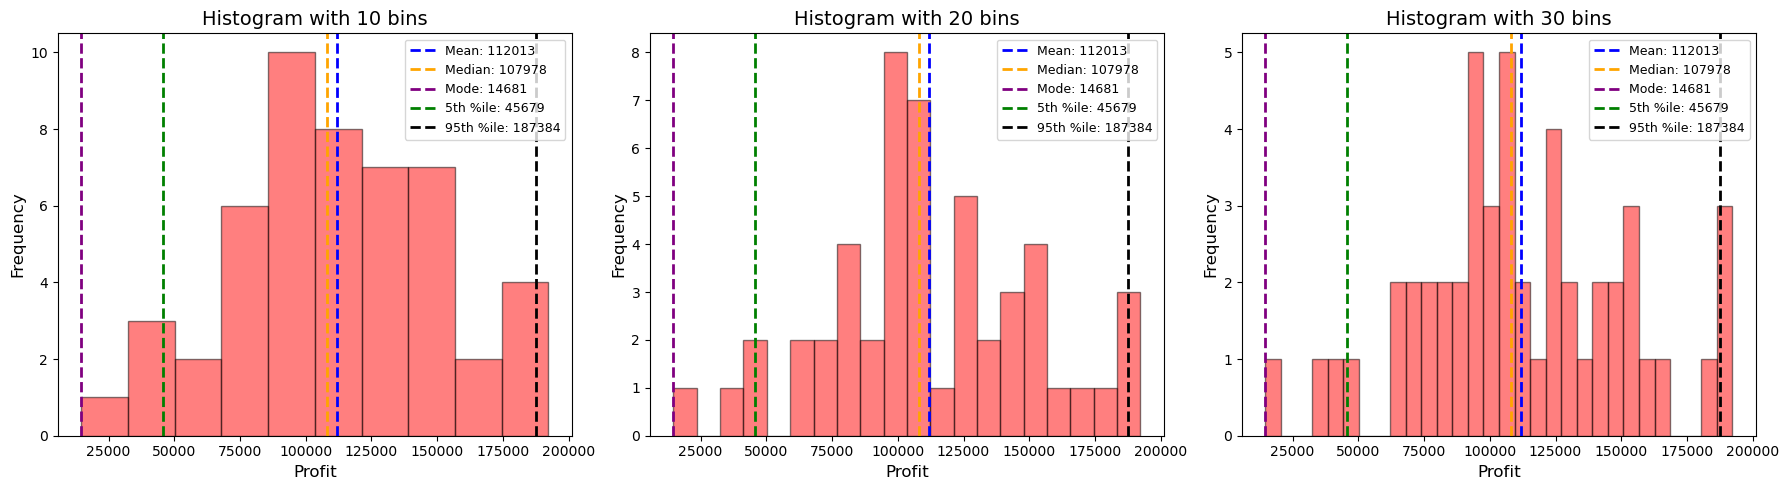

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')

# Drop missing values for Profit
df = df.dropna(subset=["Profit"])

# Calculate statistics
mean = df["Profit"].mean()
median = df["Profit"].median()
mode = df["Profit"].mode()[0]   # mode() returns Series
p5 = np.percentile(df["Profit"], 5)
p95 = np.percentile(df["Profit"], 95)

# Create figure with 3 subplots (10, 20, 30 bins)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

bin_settings = [10, 20, 30]

for i, bins in enumerate(bin_settings):
    axes[i].hist(df["Profit"], bins=bins, color='red', alpha=0.5, edgecolor='black')
    axes[i].set_title(f"Histogram with {bins} bins", fontsize=14)
    axes[i].set_xlabel("Profit", fontsize=12)
    axes[i].set_ylabel("Frequency", fontsize=12)
    
    # Add vertical reference lines
    axes[i].axvline(mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean:.0f}')
    axes[i].axvline(median, color='orange', linestyle='--', linewidth=2, label=f'Median: {median:.0f}')
    axes[i].axvline(mode, color='purple', linestyle='--', linewidth=2, label=f'Mode: {mode:.0f}')
    axes[i].axvline(p5, color='green', linestyle='--', linewidth=2, label=f'5th %ile: {p5:.0f}')
    axes[i].axvline(p95, color='black', linestyle='--', linewidth=2, label=f'95th %ile: {p95:.0f}')
    
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()


   R&D Spend  Administration  Marketing Spend     State     Profit
0  165349.20       136897.80        471784.10       NaN  192261.83
1  162597.70       151377.59        443898.53       NaN  191792.06
2  153441.51       101145.55        407934.54   Florida  191050.39
3  144372.41       118671.85        383199.62  New York  182901.99
4  142107.34        91391.77        366168.42   Florida  166187.94


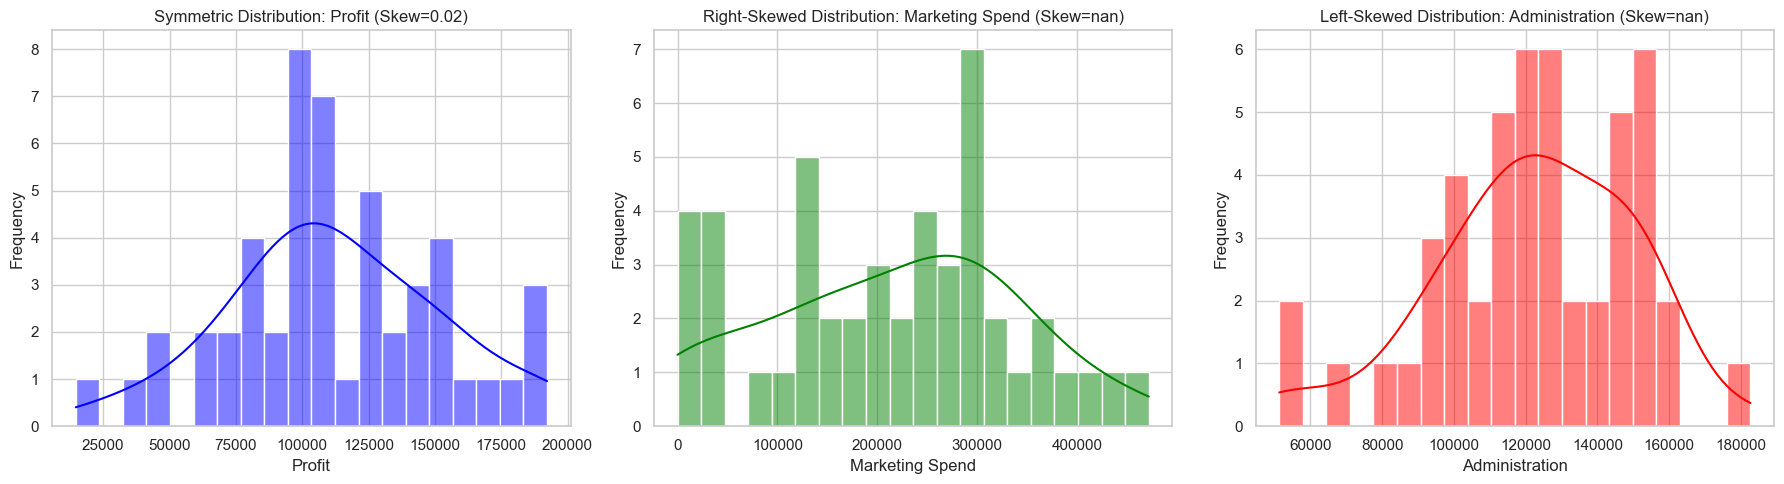

In [9]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Load dataset
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')

# Check first few rows
print(df.head())

# Set seaborn style
sns.set(style='whitegrid')

# Create a figure
plt.figure(figsize=(18,5))

# 1. Symmetric Distribution: Profit
plt.subplot(1, 3, 1)
sns.histplot(df['Profit'], kde=True, color='blue', bins=20)
plt.title(f'Symmetric Distribution: Profit (Skew={skew(df["Profit"]):.2f})')
plt.xlabel('Profit')
plt.ylabel('Frequency')

# 2. Right-Skewed Distribution: Marketing Spend
plt.subplot(1, 3, 2)
sns.histplot(df['Marketing Spend'], kde=True, color='green', bins=20)
plt.title(f'Right-Skewed Distribution: Marketing Spend (Skew={skew(df["Marketing Spend"]):.2f})')
plt.xlabel('Marketing Spend')
plt.ylabel('Frequency')

# 3. Left-Skewed Distribution: Administration
plt.subplot(1, 3, 3)
sns.histplot(df['Administration'], kde=True, color='red', bins=20)
plt.title(f'Left-Skewed Distribution: Administration (Skew={skew(df["Administration"]):.2f})')
plt.xlabel('Administration')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Log transformation 
- log transformation replace each valuess x with log(x +1) to handle zeros safely.
- it is used for right swed data, where a few large values stretch the scale.
- this compresses large values, and spread out smaller one , making more symmetric.
- it impore visualization and help model that assume normality
- after transfomation, histogram look more balanced and extreme value have less impact.

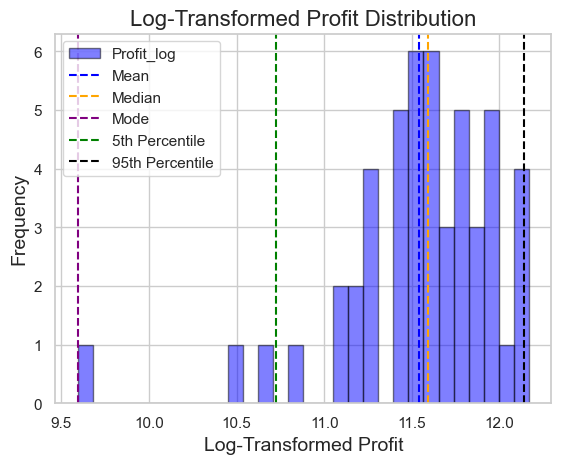

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Log transformation for positive skew
df['Profit_log'] = np.log1p(df['Profit'])  # Using log1p to avoid log(0) issues

# Calculate updated statistics for the transformed data
log_mean = df['Profit_log'].mean()
log_median = df['Profit_log'].median()
log_mode = df['Profit_log'].mode()[0]  # Mode returns a Series
log_p5 = np.percentile(df['Profit_log'], 5)
log_p95 = np.percentile(df['Profit_log'], 95)

# Plot transformed data with histogram
df['Profit_log'].plot(kind='hist', bins=30, color='blue', alpha=0.5, edgecolor='black')
plt.xlabel('Log-Transformed Profit', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Log-Transformed Profit Distribution', fontsize=16)

# Overlay statistical lines for transformed data
plt.axvline(log_mean, color='blue', linestyle='dashed', label='Mean')
plt.axvline(log_median, color='orange', linestyle='dashed', label='Median')
plt.axvline(log_mode, color='purple', linestyle='dashed', label='Mode')
plt.axvline(log_p5, color='green', linestyle='dashed', label='5th Percentile')
plt.axvline(log_p95, color='black', linestyle='dashed', label='95th Percentile')

plt.legend()
plt.show()


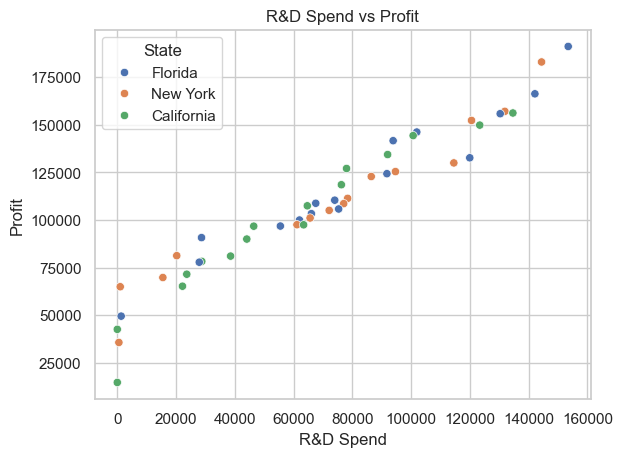

In [11]:
sns.scatterplot(x='R&D Spend', y='Profit', hue='State', data=df); plt.title('R&D Spend vs Profit'); plt.show()

In [12]:
import plotly.express as px 
# 2d
import pandas as pd
px.scatter(df, x='Marketing Spend', y='Profit' )

In [13]:
# Add Color by Category (State)
px.scatter(df, x='Marketing Spend', y='Profit', color='State',
           title="Profit vs Marketing Spend (by State)")


In [14]:
df['R&D Spend'] = df['R&D Spend'].fillna(df['R&D Spend'].mean())


In [15]:
# 2. Add Size (Bubble Chart)
px.scatter(df, x='Marketing Spend', y='Profit', size='R&D Spend',
           color='State', hover_data=['Administration'],
           title="Profit vs Marketing Spend (Bubble Size = R&D Spend)")
# X-axis: Marketing Spend, Y-axis: Profit, Bubble size: R&D Spend,Color: State,Hover info: Administration

In [16]:
px.scatter_3d(df, x='Marketing Spend', y='Profit', z='Administration')

In [17]:
import plotly.express as px
px.scatter(df, x='Marketing Spend', y='Profit', trendline="ols",
           title="Profit vs Marketing Spend with Regression Line")
# This code creates a scatter plot showing the relationship between Marketing Spend and Profit. 
# The trendline="ols" adds a linear regression line to highlight the overall trend between the two variables.


In [18]:
# Animated Scatter (Time/Category)
px.scatter(df, x='Marketing Spend', y='Profit', 
           size='R&D Spend', color='State', 
           animation_frame='State',
           title="Animated Scatter by State")
# This code creates an animated scatter plot where each point represents a row in `df`,
#  plotting **Marketing Spend** on the x-axis 
# and **Profit** on the y-axis. 
# The size of each bubble reflects **R&D Spend**, the color differentiates **State**, and the `animation_frame='State'` animates the plot to show changes for each state over frames.


In [19]:
df.drop(["State"],axis= 1,inplace= True)

In [20]:
df.corr()

,R&D Spend,Administration,Marketing Spend,Profit,Profit_log
R&D Spend,1.000000,0.230597,0.734356,0.971750,0.872538
Administration,0.230597,1.000000,-0.051490,0.194036,0.210650
Marketing Spend,0.734356,-0.051490,1.000000,0.751986,0.672486
Profit,0.971750,0.194036,0.751986,1.000000,0.933916
Profit_log,0.872538,0.210650,0.672486,0.933916,1.000000


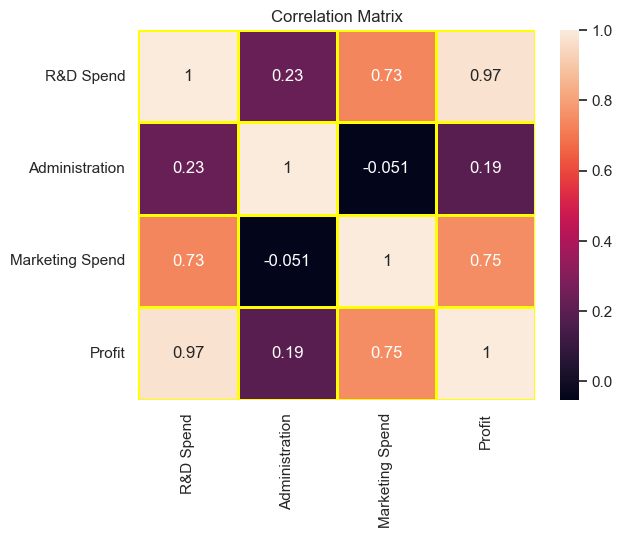

In [21]:
sns.heatmap(df[['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']].corr(), annot=True,linewidths=2, linecolor="yellow"); plt.title('Correlation Matrix'); plt.show() 

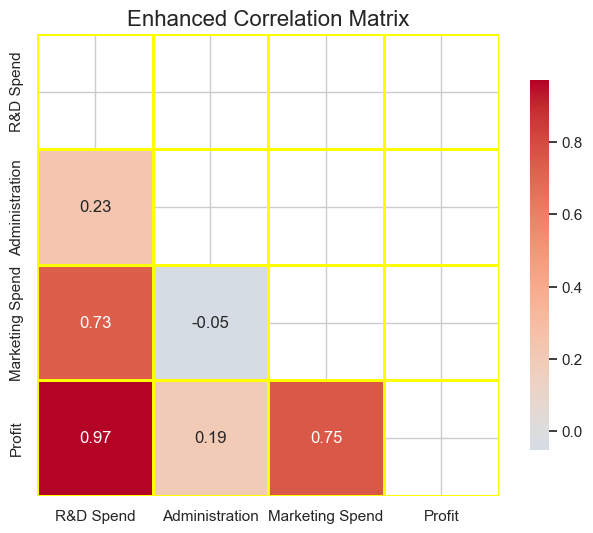

In [22]:


corr = df[['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', linewidths=2, linecolor="yellow",
            mask=mask, cmap='coolwarm', center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Enhanced Correlation Matrix", fontsize=16)
plt.show()


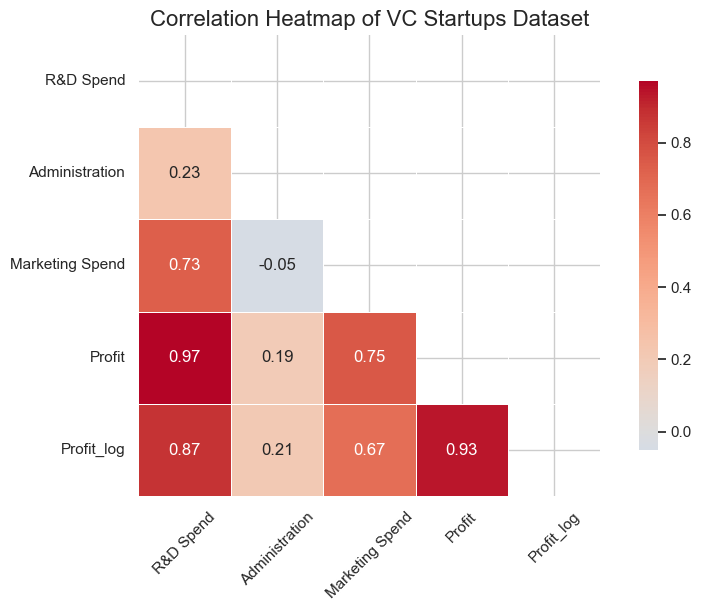

In [24]:

# Compute correlation matrix
matrix = df.corr()

# Create a mask for upper triangle
mask = np.triu(np.ones_like(matrix, dtype=bool))

# Plot enhanced heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap of VC Startups Dataset", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


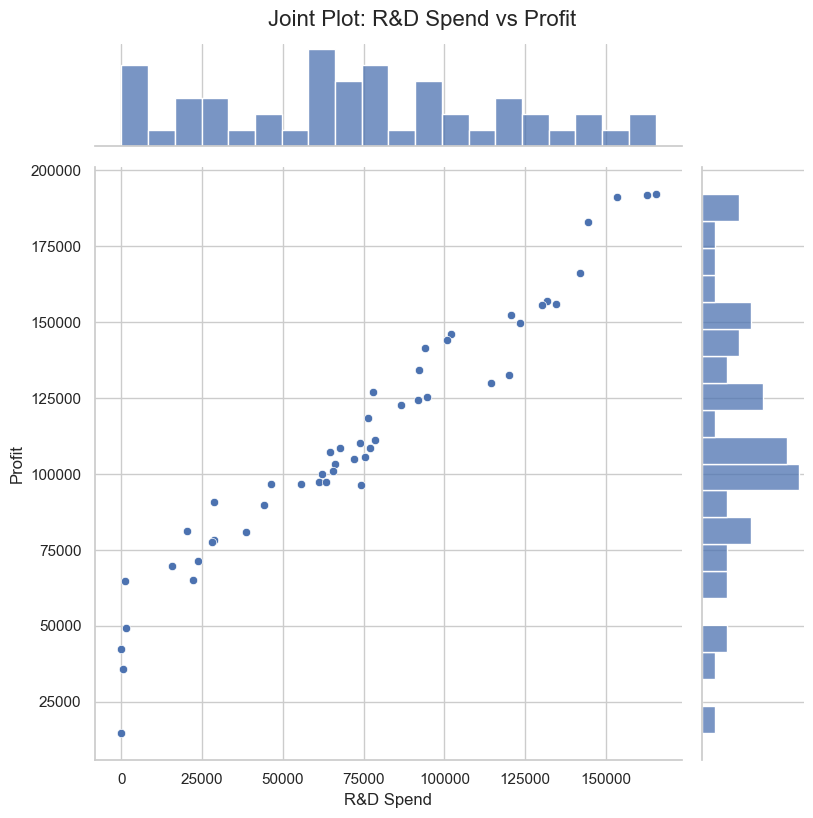

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the VC_Startups dataset
# Relationship between 'R&D Spend' and 'Profit'
sns.jointplot(
    data=df,
    x='R&D Spend',
    y='Profit',
    kind='scatter',   # options: 'scatter', 'reg', 'kde', 'hex'
    height=8,         # size of plot
    marginal_kws=dict(bins=20, fill=True)  # histogram style
)

plt.suptitle("Joint Plot: R&D Spend vs Profit", fontsize=16,=
plt.show()


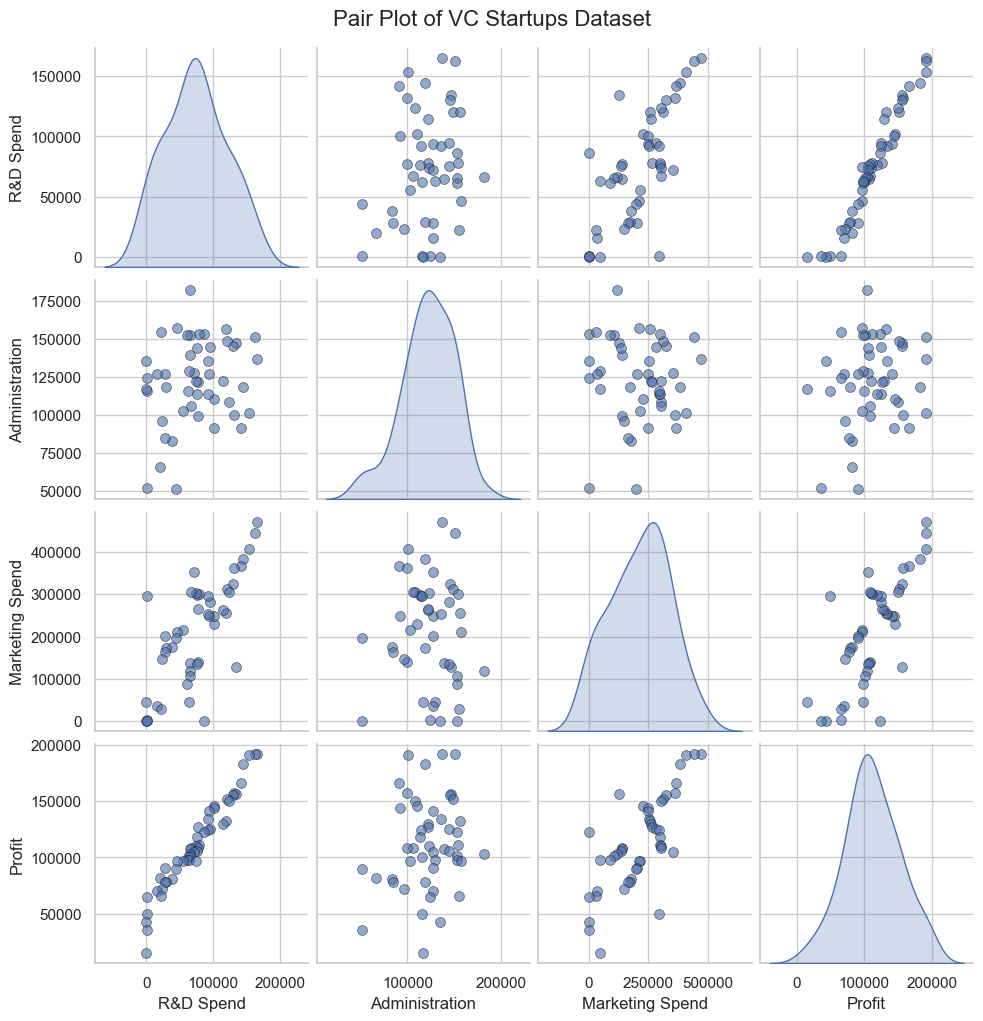

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns from VC_Startups dataset
numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']

# Create pair plot
sns.pairplot(df[numeric_cols], 
             kind='scatter',       # scatter plots for relationships
             diag_kind='kde',      # KDE for diagonal (distribution)
             height=2.5,           # size of each subplot
             plot_kws={'alpha':0.6, 's':50, 'edgecolor':'k'})  # scatter aesthetics

plt.suptitle("Pair Plot of VC Startups Dataset", fontsize=16, y=1.02)
plt.show()


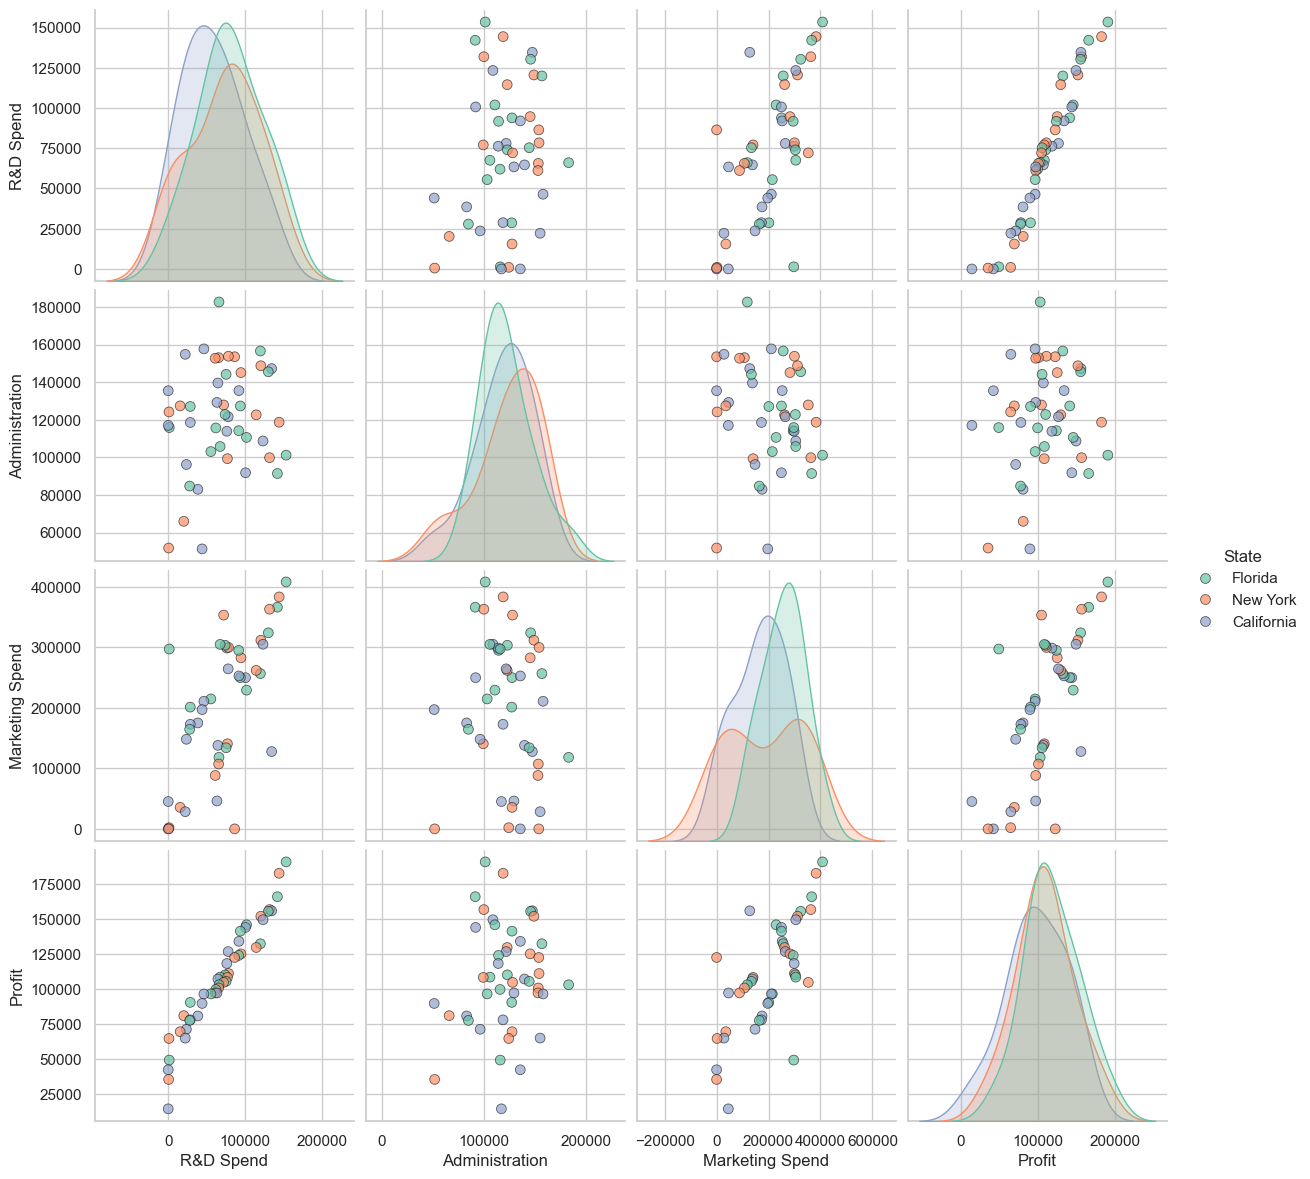

In [ ]:
df = pd.read_csv('/Users/rashmithav/Documents/Dataminds/04. Datasets-Masters/Dataset-Master 1/VC_Startups.csv')
sns.pairplot(df, 
             vars=['R&D Spend', 'Administration', 'Marketing Spend', 'Profit'],
             hue='State',          # color by category
             diag_kind='kde',      # density plots on diagonal
             palette='Set2',       # color palette
             height=3, 
             plot_kws={'alpha':0.7, 's':50, 'edgecolor':'k'})


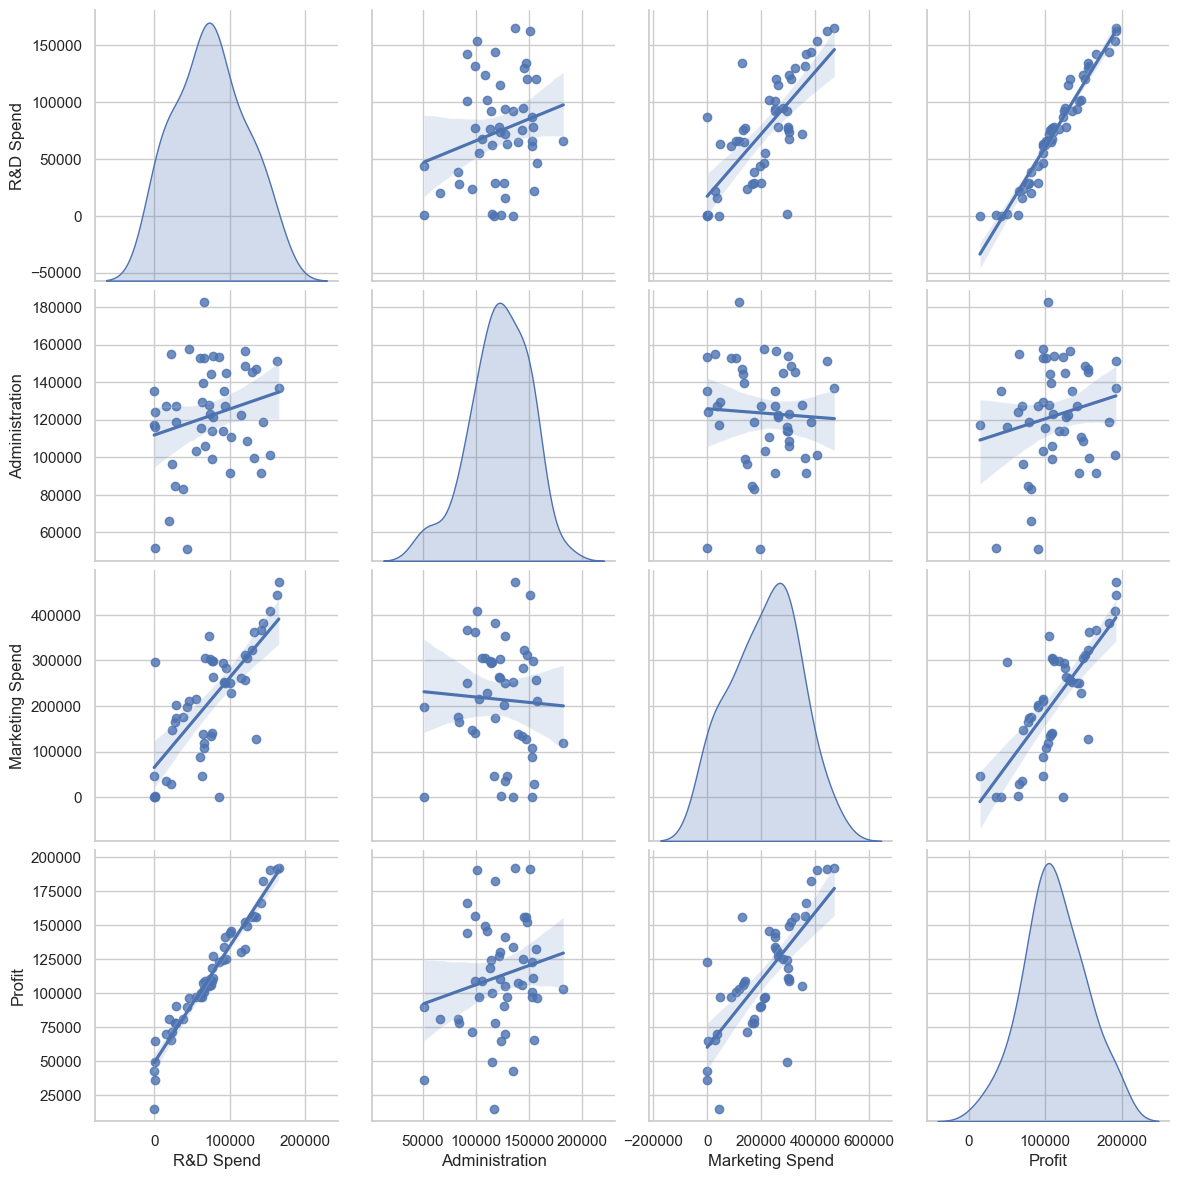

In [ ]:
sns.pairplot(df, 
             vars=['R&D Spend', 'Administration', 'Marketing Spend', 'Profit'],
             kind='reg', 
             diag_kind='kde', 
             height=3)


In [ ]:
import plotly.express as px

# Select numeric columns
numeric_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']

# Create interactive scatter matrix (pair plot)
fig = px.scatter_matrix(
    df,
    dimensions=numeric_cols,   # columns to include
    color='State' if 'State' in df.columns else None,  # color by State if available
    title="Interactive Pair Plot of VC Startups Dataset",
    labels={col: col.replace(" ", "\n") for col in numeric_cols},  # nicer axis labels
    hover_data=df.columns      # show all info on hover
)

# Improve layout aesthetics
fig.update_traces(diagonal_visible=False, marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(height=800, width=800)

fig.show()


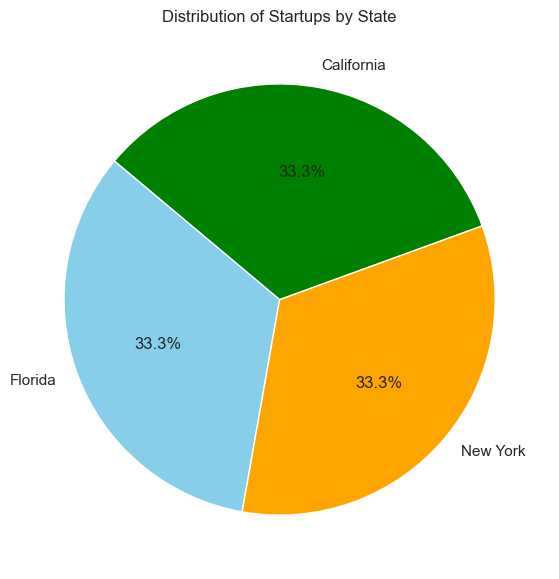

In [ ]:
import matplotlib.pyplot as plt

# Example: Count of startups by State (if State column exists)
state_counts = df['State'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue','orange','green','red','purple'])
plt.title("Distribution of Startups by State")
plt.show()


Text(0.5, 1.0, 'Donut Chart of Startups by State')

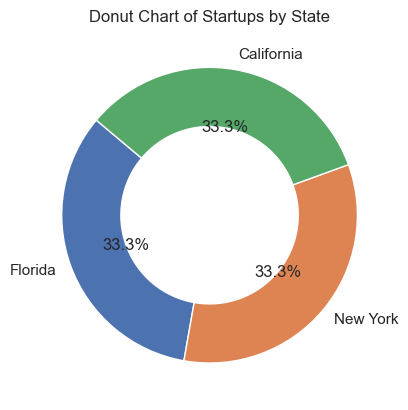

In [ ]:
plt.pie(state_counts, labels=state_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops={'width':0.4})
plt.title("Donut Chart of Startups by State")
